<a href="https://colab.research.google.com/github/darrickpang/Email/blob/master/Trajectory_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install nuscenes-devkit torch numpy matplotlib tqdm

In [3]:
# =========================
# 1. Imports & Setup
# =========================
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

from nuscenes.nuscenes import NuScenes
from nuscenes.map_expansion.map_api import NuScenesMap

SCALE = 10.0  # meters

Mounted at /content/drive


In [4]:
# =========================
# 2. Load nuScenes
# =========================
DATA_ROOT = "/content/drive/MyDrive/nuscenes"

nusc = NuScenes(
    version="v1.0-mini",
    dataroot=DATA_ROOT,
    verbose=True
)

print("Scenes:", len(nusc.scene))

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 5.962 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.
Scenes: 10


In [5]:
# =========================
# 3. Load Map for Scene
# =========================
scene = nusc.scene[0]
log = nusc.get("log", scene["log_token"])
map_name = log["location"]

nusc_map = NuScenesMap(
    dataroot=DATA_ROOT,
    map_name=map_name
)

print("Using map:", map_name)

Using map: singapore-onenorth


We want to find the center-line on the road because this adds context such as road direction and vehicle position on the road relative to the center.

In [6]:
# =========================
# 4. Lane Feature Helper
# =========================
import numpy as np

def get_nearest_lane_features(nusc_map, x, y, radius=20.0):
    lanes = nusc_map.get_records_in_radius(x, y, radius=radius, layer_names=["lane"])
    if len(lanes["lane"]) == 0:
        return None

    # Try lanes until we find one with a valid centerline
    for lane_token in lanes["lane"]:
        centerline = nusc_map.get_arcline_path(lane_token)

        # centerline can be empty or oddly structured; normalize to Nx2 array
        if centerline is None or len(centerline) < 2:
            continue

        centerline = np.asarray(centerline)

        # Sometimes it becomes 1D; try to reshape if it's a flat list of points
        if centerline.ndim == 1:
            # If it’s something like [x, y, x, y, ...] or a list of tuples collapsed
            # we can't safely recover -> skip
            continue

        # Keep only x,y
        xy = centerline[:, :2]
        if xy.shape[0] < 2:
            continue

        # Closest point on lane
        dists = np.linalg.norm(xy - np.array([x, y]), axis=1)
        idx = int(np.argmin(dists))
        lane_point = xy[idx]

        # Approx lane direction (heading)
        if idx < len(xy) - 1:
            direction = xy[idx + 1] - lane_point
        else:
            direction = lane_point - xy[idx - 1]

        norm = np.linalg.norm(direction)
        if norm < 1e-6:
            continue

        heading = np.arctan2(direction[1], direction[0])

        # Signed lateral offset (2D cross product z-component / ||direction||)
        lateral_offset = (direction[0] * (y - lane_point[1]) - direction[1] * (x - lane_point[0])) / norm

        return lateral_offset, heading

    return None

We will be using
```python
def get_vehicle_trajectory(nusc, instance_token):
```
to extract the vehicle trajectory of a single vehicle instance using the time-ordered (x, y) trajectory. This means that code will convert each frame into continuous trajectories.

In [7]:
# =========================
# 5. Lane-Aware Trajectory Extraction
# =========================
def get_vehicle_lane_trajectory(nusc, nusc_map, instance_token):
    traj = []
    instance = nusc.get("instance", instance_token)
    ann_token = instance["first_annotation_token"]

    while ann_token:
        ann = nusc.get("sample_annotation", ann_token)
        x, y, _ = ann["translation"]

        lane_feat = get_nearest_lane_features(nusc_map, x, y, radius=20.0)
        if lane_feat is None:
            offset, heading = 0.0, 0.0
        else:
            offset, heading = lane_feat

        sample = nusc.get("sample", ann["sample_token"])
        t = sample["timestamp"]

        traj.append((t, x, y, offset, heading))
        ann_token = ann["next"]

    traj.sort(key=lambda z: z[0])
    return traj

This is window sizes that will determine how much we want to use as input (past) and output (future).

In [8]:
# =========================
# 6. Windowing Parameters
# =========================
PAST_LEN = 8
FUTURE_LEN = 12

In addition, we have
```python
def create_trajectory_samples(traj):
```
so we can convert raw trajectories into supervised learning data

In [9]:
# =========================
# 7. Create Samples
# =========================
def create_trajectory_samples(traj):
    samples = []
    feats = np.array([[p[1], p[2], p[3], p[4]] for p in traj])

    for i in range(len(feats) - PAST_LEN - FUTURE_LEN):
        past = feats[i : i + PAST_LEN]
        future = feats[i + PAST_LEN : i + PAST_LEN + FUTURE_LEN]
        samples.append((past, future))

    return samples

We will collect vehicle instances per scene to ensure valid, continuous annotation chains.

In [10]:
# =========================
# 8. Collect Vehicle Instances
# =========================
vehicle_instances = []
for inst in nusc.instance:
    cat = nusc.get("category", inst["category_token"])
    if cat["name"].startswith("vehicle"):
        vehicle_instances.append(inst)

print("Vehicle instances:", len(vehicle_instances))

Vehicle instances: 476


This step the final supervised past-future trajectory pair data set needed to train our DL model.

In [12]:
# =========================
# 9. Build Dataset
# =========================
all_samples = []

for inst in vehicle_instances:
    traj = get_vehicle_lane_trajectory(nusc, nusc_map, inst["token"])
    if len(traj) < PAST_LEN + FUTURE_LEN:
        continue

    all_samples.extend(create_trajectory_samples(traj))

print("Total samples:", len(all_samples))

Total samples: 2532


We need to normalize trajectories to transform trajectories into an ego-relative frame by subtracting the last past point. This removes absolute position bias and helps the model learn motion patterns instead of location. We will also scale them for numerical stability.

In [13]:
# =========================
# 10. Normalization
# =========================
# def normalize(past, future):
#     origin_xy = past[-1, :2]

#     past[:, :2] -= origin_xy
#     future[:, :2] -= origin_xy

#     return past, future

We use
```python
class TrajectoryDataset(Dataset):
```
to wrap the trajectory samples into a PyTorch-compatible dataset so they can be:
1. batched,
2. shuffled,
3. loaded efficiently during training.

In [45]:
import torch
from torch.utils.data import Dataset

# =========================
# 11. PyTorch Dataset
# =========================

# class TrajectoryDataset(Dataset):
#     def __init__(self, samples):
#         self.data = []
#         for past, future in samples:
#             origin = past[-1, :2].copy()

#             # shift to local frame
#             past[:, :2] -= origin
#             future[:, :2] -= origin

#             # scale normalization
#             past[:, :2] /= SCALE
#             future[:, :2] /= SCALE

#             future_xy = future[:, :2]

#             future_disp = torch.zeros_like(future_xy)
#             future_disp[0] = future_xy[0]                 # displacement from (0,0)
#             future_disp[1:] = future_xy[1:] - future_xy[:-1]  # displacement from last past point

#             self.data.append((past, future_disp))

#     def __len__(self):
#         return len(self.data)

#     def __getitem__(self, idx):
#         past, future, origin = self.data[idx]
#         return (
#             torch.tensor(past, dtype=torch.float32),
#             torch.tensor(future, dtype=torch.float32),
#             torch.tensor(origin, dtype=torch.float32),
#         )

Split data into training and validation. 80 percent to 20 percent.

In [58]:
# =========================
# 12. DataLoaders
# =========================
import torch # Added this import for the class definition
from torch.utils.data import Dataset # Added this import for the class definition
from torch.utils.data import random_split

# Redefine TrajectoryDataset with the fix for .clone() and storing origin
class TrajectoryDataset(Dataset):
    def __init__(self, samples):
        self.data = []
        for past, future in samples:
            # Ensure we operate on copies if modifying in-place before conversion
            past_data = past.copy()
            future_data = future.copy()

            origin_xy = past_data[-1, :2].copy() # Get the origin for the current sample

            # shift to local frame
            past_data[:, :2] -= origin_xy
            future_data[:, :2] -= origin_xy

            # scale normalization
            past_data[:, :2] /= SCALE
            future_data[:, :2] /= SCALE

            future_xy = future_data[:, :2] # This is still a numpy array slice

            # Corrected: Create a copy of future_xy (numpy array), then compute displacements
            future_disp_np = future_xy.copy() # Use .copy() for numpy array
            future_disp_np[1:] = future_xy[1:] - future_xy[:-1]
            # future_disp_np[0] already holds future_xy[0] (displacement from last past point)

            self.data.append((past_data, future_disp_np, origin_xy)) # Store all three required items

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        past, future_disp, origin = self.data[idx]
        return (
            torch.tensor(past, dtype=torch.float32),
            torch.tensor(future_disp, dtype=torch.float32),
            torch.tensor(origin, dtype=torch.float32),
        )

dataset = TrajectoryDataset(all_samples)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)


In [59]:
past, future_disp, _ = dataset[0]
print((future_disp[:, :2] * SCALE)[:5])

tensor([[ 1.3560e-11, -9.8000e-12],
        [ 8.3700e-13, -5.7200e-13],
        [ 9.0600e-14,  1.5570e-13],
        [ 1.0880e-14,  1.4670e-14],
        [ 1.3400e-15,  1.4670e-15]])


This step defines a sequence model that:
1. encodes past motion using an LSTM,
2. predicts the final future position (x, y).

This is a standard baseline for trajectory prediction.

In [54]:
import torch.nn as nn

# =========================
# 13. LSTM Model (Lane-Aware)
# =========================
class LSTMMultiStepPredictor(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=64, future_len=12, num_layers=1):
        super().__init__()
        self.future_len = future_len
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, future_len * 2)  # predict (x,y) for each future step

    def forward(self, past):
        # past: [B, PAST_LEN, input_dim]
        _, (h_n, _) = self.lstm(past)
        h = h_n[-1]                         # [B, hidden_dim]
        out = self.fc(h)                    # [B, future_len*2]
        out = out.view(-1, self.future_len, 2)  # [B, future_len, 2]
        return out

This is the training setup where we configure:
1. loss function (mean squared error),
2. optimizer (Adam),
3. learning rate.

This defines how the model learns.

In [55]:
# =========================
# 14. Training
# =========================
device = "cuda" if torch.cuda.is_available() else "cpu"

model = LSTMMultiStepPredictor(input_dim=4, hidden_dim=64, future_len=FUTURE_LEN).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 20

for epoch in range(EPOCHS):
    model.train()
    criterion = nn.MSELoss()
    loss_sum = 0

    for past, future, origin in train_loader:  # origin can stay even if unused
      past = past.to(device)
      future = future.to(device)

      pred_traj = model(past)              # [B, FUTURE_LEN, 2] (scaled local)
      target_traj = future[:, :, :2]       # [B, FUTURE_LEN, 2] (scaled local)

      loss = criterion(pred_traj, target_traj)

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      loss_sum += loss.item()

    print(f"Epoch {epoch+1:02d} | Train Loss: {loss_sum / len(train_loader):.3f}")

Epoch 01 | Train Loss: 0.980
Epoch 02 | Train Loss: 0.921
Epoch 03 | Train Loss: 0.927
Epoch 04 | Train Loss: 0.921
Epoch 05 | Train Loss: 0.925
Epoch 06 | Train Loss: 0.925
Epoch 07 | Train Loss: 0.933
Epoch 08 | Train Loss: 0.925
Epoch 09 | Train Loss: 0.926
Epoch 10 | Train Loss: 0.926
Epoch 11 | Train Loss: 0.926
Epoch 12 | Train Loss: 0.928
Epoch 13 | Train Loss: 0.925
Epoch 14 | Train Loss: 0.912
Epoch 15 | Train Loss: 0.941
Epoch 16 | Train Loss: 0.922
Epoch 17 | Train Loss: 0.912
Epoch 18 | Train Loss: 0.918
Epoch 19 | Train Loss: 0.924
Epoch 20 | Train Loss: 0.916


This is the evaluation metric to calculate the Final Displacement Error (FDE), a standard AV metric measuring distance between predicted and true final positions.

This directly measures prediction accuracy.

In [56]:
# =========================
# 15. Evaluation (FDE)
# =========================
def ade_fde(pred_traj, gt_traj, scale=10.0):
    """
    pred_traj, gt_traj: [B, T, 2] in scaled local coordinates
    returns ADE, FDE in meters
    """
    pred_m = pred_traj * scale
    gt_m = gt_traj * scale

    dists = torch.norm(pred_m - gt_m, dim=2)   # [B, T]
    ade = dists.mean().item()
    fde = dists[:, -1].mean().item()
    return ade, fde

model.eval()
ade_sum, fde_sum, n_batches = 0.0, 0.0, 0

with torch.no_grad():
    for past, future, origin in val_loader:
        past = past.to(device)
        future = future.to(device)

        pred_traj = model(past)           # [B, T, 2]
        gt_traj = future[:, :, :2]        # [B, T, 2]

        ade, fde = ade_fde(pred_traj, gt_traj, scale=SCALE)
        ade_sum += ade
        fde_sum += fde
        n_batches += 1

print("Validation ADE (m):", ade_sum / n_batches)
print("Validation FDE (m):", fde_sum / n_batches)

Validation ADE (m): 2.25441412627697
Validation FDE (m): 24.073656797409058


Plot

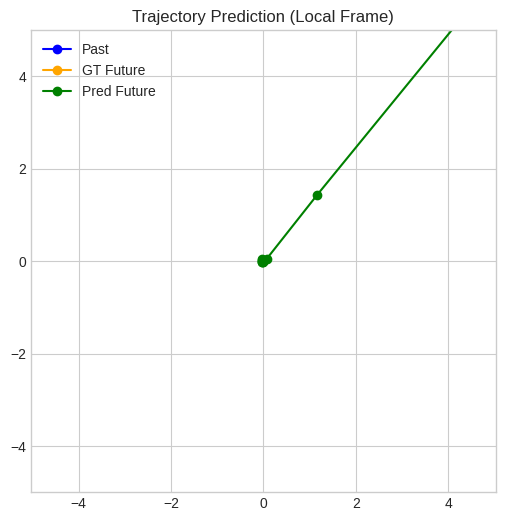

In [57]:
# =========================
# 16. Visualization
# =========================
import matplotlib.pyplot as plt

model.eval()
past, future_disp, origin = dataset[0]

past_in = past.unsqueeze(0).to(device)

with torch.no_grad():
    pred_disp = model(past_in).cpu().squeeze(0)   # [T, 2]

# Ground-truth displacements
gt_disp = future_disp[:, :2]

# 🔑 RECONSTRUCT POSITIONS
pred_xy = torch.cumsum(pred_disp, dim=0) * SCALE
gt_xy   = torch.cumsum(gt_disp, dim=0) * SCALE
past_xy = past[:, :2] * SCALE

plt.figure(figsize=(6, 6))
plt.plot(past_xy[:, 0], past_xy[:, 1], "b-o", label="Past")
plt.plot(gt_xy[:, 0], gt_xy[:, 1], "orange", marker="o", label="GT Future")
plt.plot(pred_xy[:, 0], pred_xy[:, 1], "g", marker="o", label="Pred Future")
plt.legend()
plt.axis("equal")
# 🔑 ZOOM
plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.title("Trajectory Prediction (Local Frame)")
plt.show()